In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scipy
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import PathCollection
import muon as mu

/opt/anaconda3/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Read in data and filter out any contaminating T cells
adata = mu.read('../data/GSE303452_GEO_data_file_v1.h5mu')
print(adata.shape)

(38231, 29034)


/opt/anaconda3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
adata = adata[adata.obs['pct_counts_mt'] <= 5]
print(adata.shape)

(34494, 29034)


In [4]:
# 
ifn_genes = []
for i in adata.var.index:
    if ('IFN' in i) & ('R' not in i) & ('AS1' not in i):
        ifn_genes.append(i)
    elif i == 'TGFB1':
        ifn_genes.append(i)  
ifn_genes   

['IFNB1', 'IFNG', 'IFNK', 'IFNL1', 'IFNL3', 'TGFB1']

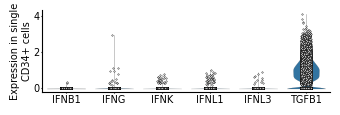

In [6]:
# Plot the expression of IFN on various graphs 

plt.rcParams['pdf.fonttype'] = 42
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (3.5, 1.25))

sc.pl.violin(adata['rna'], keys=ifn_genes,  linewidth=0.1, ax = ax, rasterized = True, use_raw= False, show=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(pad = 1, length = 1, labelsize = 7)
ax.set_ylabel(ylabel = 'Expression in single\nCD34+ cells', labelpad = 1, fontsize = 7)


# Rasterize ALL artists on the axes
for collection in ax.collections:
    if isinstance(collection, PathCollection):  # dots only
        collection.set_facecolor('white')
        collection.set_edgecolor('black')
        collection.set_linewidth(0.3)
        collection.set_rasterized(True)



plt.tight_layout()
#fig.savefig('../result/ifn_expression_in_cd34_cells.pdf', dpi = 1200)
